In [52]:
import os
import numpy as np
import pandas as pd

HOUSING_PATH = "datasets/housing"
csv_path = os.path.join(HOUSING_PATH, "housing-census-data-preprocessed.csv")
housing = pd.read_csv(csv_path)
housing.head()

,census_block_group,Median Household Income,Population,Medium Number of Rooms,Median Housing Age,Median Value: Owner-occupied housing units,Median Household Bedrooms
0,60014001001,15,3018,6.9,1992.0,1074100.0,3
1,60014002001,15,1105,6.6,1939.0,1022900.0,3
2,60014002002,14,764,5.7,1939.0,875000.0,2
3,60014003001,15,1466,6.3,1939.0,1316400.0,3
4,60014003002,12,1229,4.7,1939.0,828200.0,2


In [53]:
housing = housing.drop(["census_block_group"], axis=1)
housing.describe()

,Median Household Income,Population,Medium Number of Rooms,Median Housing Age,Median Value: Owner-occupied housing units,Median Household Bedrooms
count,23212.000000,23212.000000,23068.000000,22808.000000,2.157700e+04,23212.000000
mean,10.209461,1630.114639,5.152272,1968.817520,4.830773e+05,2.622092
std,2.945497,996.473910,1.183951,15.909336,3.418449e+05,0.790845
min,1.000000,0.000000,1.300000,1939.000000,9.999000e+03,0.000000
25%,8.000000,1008.000000,4.300000,1957.000000,2.636000e+05,2.000000
50%,11.000000,1434.000000,5.100000,1969.000000,3.909000e+05,3.000000
75%,12.000000,2024.000000,5.900000,1980.000000,6.123000e+05,3.000000
max,16.000000,23422.000000,9.000000,2013.000000,2.000001e+06,5.000000


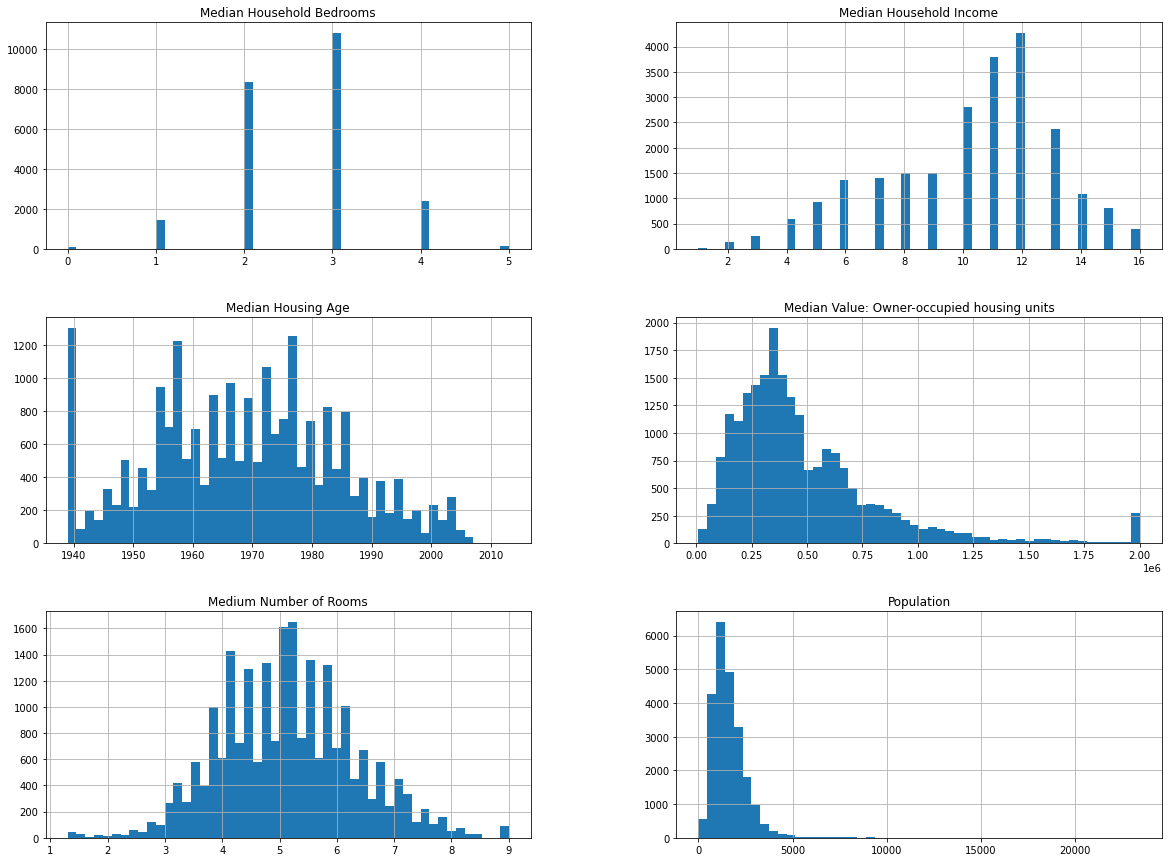

In [54]:
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20,15))
plt.show()

In [55]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["Median Household Income"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]
    
strat_test_set["Median Household Income"].value_counts() / len(strat_test_set)

12    0.183717
11    0.163687
10    0.120827
13    0.101874
8     0.064829
9     0.064613
7     0.060090
6     0.058367
14    0.046952
5     0.040276
15    0.035322
4     0.025845
16    0.016584
3     0.010984
2     0.005600
1     0.000431
Name: Median Household Income, dtype: float64

In [56]:
housing.corr()

,Median Household Income,Population,Medium Number of Rooms,Median Housing Age,Median Value: Owner-occupied housing units,Median Household Bedrooms
Median Household Income,1.000000,0.022435,0.611271,0.091862,0.597141,0.524639
Population,0.022435,1.000000,0.068274,0.366348,-0.112749,0.094245
Medium Number of Rooms,0.611271,0.068274,1.000000,0.206738,0.292617,0.866956
Median Housing Age,0.091862,0.366348,0.206738,1.000000,-0.194031,0.263598
Median Value: Owner-occupied housing units,0.597141,-0.112749,0.292617,-0.194031,1.000000,0.147606
Median Household Bedrooms,0.524639,0.094245,0.866956,0.263598,0.147606,1.000000


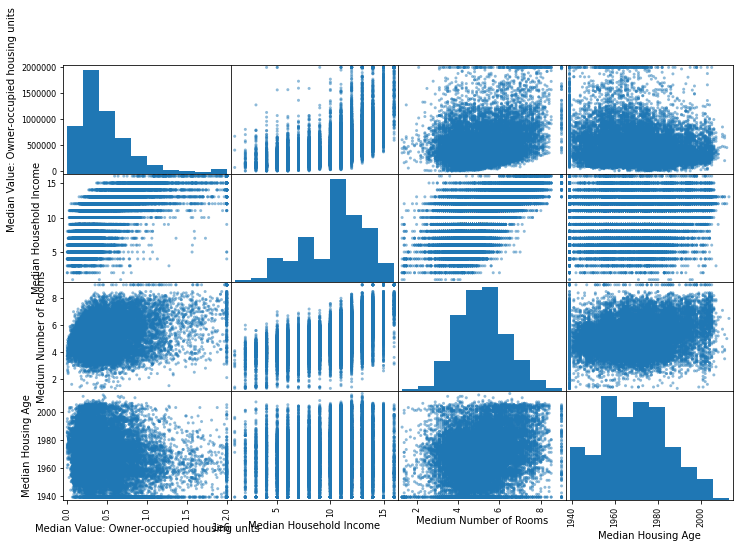

In [57]:
from pandas.plotting import scatter_matrix

attributes = ["Median Value: Owner-occupied housing units", "Median Household Income", "Medium Number of Rooms",
              "Median Housing Age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

In [58]:
# some NA labels
strat_train_set = strat_train_set[strat_train_set["Median Value: Owner-occupied housing units"].notna()]
housing = strat_train_set.drop(["Median Value: Owner-occupied housing units"], axis=1) # drop labels for training set
housing_labels = strat_train_set["Median Value: Owner-occupied housing units"].copy().reset_index(drop=True)
housing.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 17269 entries, 10635 to 16260
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Median Household Income    17269 non-null  int64  
 1   Population                 17269 non-null  int64  
 2   Medium Number of Rooms     17268 non-null  float64
 3   Median Housing Age         17055 non-null  float64
 4   Median Household Bedrooms  17269 non-null  int64  
dtypes: float64(2), int64(3)
memory usage: 809.5 KB


In [59]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = [
    # try 12 (3×4) combinations of hyperparameters
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    # then try 6 (2×3) combinations with bootstrap set as False
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
]

housing_num = housing.select_dtypes(include=[np.number]) # select only numeric to then pass into imputer
housing_num

,Median Household Income,Population,Medium Number of Rooms,Median Housing Age,Median Household Bedrooms
10635,11,1441,4.7,1959.0,2
18063,14,826,4.8,1959.0,2
14781,12,1547,6.6,1989.0,3
9913,12,1621,5.3,1984.0,3
5270,4,1590,4.2,1947.0,2
...,...,...,...,...,...
10420,6,3840,5.2,1994.0,3
4215,12,1433,4.9,1950.0,3
1627,14,704,6.7,1956.0,3
4488,8,903,4.1,1962.0,2


In [60]:
num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('std_scaler', StandardScaler()),
    ])

num_attribs = list(housing_num)
num_attribs

# housing_numerical_transformed = pd.DataFrame(num_pipeline.fit_transform(housing_num, housing_labels))
# housing_numerical_transformed

['Median Household Income',
 'Population',
 'Medium Number of Rooms',
 'Median Housing Age',
 'Median Household Bedrooms']

In [61]:
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
])
housing_transformed = full_pipeline.fit_transform(housing)
housing_transformed

array([[ 0.21612427, -0.21887748, -0.48659473, -0.6204417 , -0.90768898],
       [ 1.29221752, -0.83417377, -0.39840476, -0.6204417 , -0.90768898],
       [ 0.57482202, -0.11282641,  1.18901459,  1.27950055,  0.4458108 ],
       ...,
       [ 1.29221752, -0.95623255,  1.27720456, -0.81043592,  0.4458108 ],
       [-0.85996897, -0.75713668, -1.01573452, -0.43044747, -0.90768898],
       [ 0.21612427,  0.32938654,  0.57168484,  0.32952943,  0.4458108 ]])

In [62]:
housing_transformed.shape

(17269, 5)

In [63]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(housing_transformed, housing_labels)
lin_reg.predict(some_data)

array([-1.49758133e+08, -1.43334076e+08, -1.52636147e+08, -1.53052763e+08,
       -1.51859396e+08])

In [64]:
from sklearn.metrics import mean_squared_error

housing_predictions = lin_reg.predict(housing_transformed)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

258786.10514452617

In [65]:
forest_reg = RandomForestRegressor(n_estimators=10, random_state=42)
forest_reg.fit(housing_transformed, housing_labels)

print('expected', some_labels)
forest_reg.predict(some_data)

expected 0    1168700.0
1    1300800.0
2     238700.0
3     450000.0
4     231900.0
Name: Median Value: Owner-occupied housing units, dtype: float64


array([1580780.4, 1580780.4, 1565750.4, 1565750.4, 1580780.4])

In [66]:
housing_predictions = forest_reg.predict(housing_transformed)
rf_mse = mean_squared_error(housing_labels, housing_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_rmse

97866.58831891723

In [67]:
from sklearn.model_selection import cross_val_score

rf_scores = cross_val_score(forest_reg, housing_transformed, housing_labels,
                             scoring="neg_mean_squared_error", cv=10)
rf_rmse_scores = np.sqrt(-rf_scores)

def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(rf_rmse_scores)

Scores: [238930.88362145 229893.61789337 240617.00246524 240055.35061149
 225631.21696709 239878.48850904 237017.15904307 232493.17041148
 233768.22781015 234302.60854811]
Mean: 235258.77258804924
Standard deviation: 4710.574557810863


In [68]:
full_pipeline_with_predictor = Pipeline([
    ("preparation", full_pipeline),       
    ('random forest', RandomForestRegressor(n_estimators=10, random_state=42))
])

some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]

full_pipeline_with_predictor.fit(housing, housing_labels)
print('expected', some_labels)
full_pipeline_with_predictor.predict(some_data)

expected 0    1168700.0
1    1300800.0
2     238700.0
3     450000.0
4     231900.0
Name: Median Value: Owner-occupied housing units, dtype: float64


array([ 916370., 1195920.,  261840.,  443990.,  257250.])

In [ ]:
# conclusion, our dataset is too small, need more columns